# BUDT758T - FINAL PROJECT

## Import the necessary packages

In [1]:
# Yelp Top-Useful Prediction
# Baseline Logistic Regression Version
#
# Includes:
# 1. External data source: US holiday calendar
# 2. 10+ feature insight tables/charts
# 3. Baseline logistic regression classifier
# 4. ROC curve and ROC-AUC
# 5. TPR at FPR <= 10%
# 6. Final submission generated from the validation-selected threshold

import os
import gc
import ast
import json
import re
import time
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, accuracy_score

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression


## Import dataset and configure initial settings

In [2]:
# 1. Settings

RANDOM_STATE = 42
N_JOBS = -1

# Data files are stored in the same project folder as this notebook.
DATA_DIR = r"D:\BUDT 758C - Predictive analytics\project work"
OUTPUT_DIR = DATA_DIR

# Required operating point: maximize TPR while keeping FPR at or below 10%.
FPR_LIMIT = 0.10

# change user.useful to False because it is leakage
USE_USER_USEFUL_FEATURES = False

print("Settings loaded.")


Settings loaded.


## Load datasets and inspect data structure

In [3]:
# 2. Load Data

def read_csv_from_data_dir(filename):
    path = os.path.join(DATA_DIR, filename)
    print("Reading:", path)
    return pd.read_csv(path)

# Read csv files
train_x = read_csv_from_data_dir("review_train_x.csv")
train_y = read_csv_from_data_dir("review_train_y.csv")
test_x = read_csv_from_data_dir("review_test_x.csv")
business = read_csv_from_data_dir("business_data_cleaned.csv")
user = read_csv_from_data_dir("user_clean.csv")
tip = read_csv_from_data_dir("tips_cleaned.csv")

if train_y.shape[1] == 1:
    y = train_y.iloc[:, 0].astype(int).reset_index(drop=True)
else:
    y = train_y["top_useful"].astype(int).reset_index(drop=True)

# Find distribution and shapes
print("train_x:", train_x.shape)
print("train_y:", train_y.shape)
print("test_x:", test_x.shape)
print("business:", business.shape)
print("user:", user.shape)
print("tip:", tip.shape)

print("\nLabel distribution:")
print(y.value_counts())
print("Positive rate:", y.mean())


Reading: D:\BUDT 758C - Predictive analytics\project work\review_train_x.csv
Reading: D:\BUDT 758C - Predictive analytics\project work\review_train_y.csv
Reading: D:\BUDT 758C - Predictive analytics\project work\review_test_x.csv
Reading: D:\BUDT 758C - Predictive analytics\project work\business_data_cleaned.csv
Reading: D:\BUDT 758C - Predictive analytics\project work\user_clean.csv
Reading: D:\BUDT 758C - Predictive analytics\project work\tips_cleaned.csv
train_x: (1577278, 6)
train_y: (1577278, 1)
test_x: (700000, 6)
business: (15000, 112)
user: (992656, 13)
tip: (300845, 7)

Label distribution:
top_useful
0    1386131
1     191147
Name: count, dtype: int64
Positive rate: 0.1211878945880181


## Define evaluation functions for model performance assessment

In [4]:
# ============================================================
# 3. Evaluation Functions
# ============================================================

# Find the best TPR under a specific FPR limit
def best_tpr_under_fpr(y_true, y_score, fpr_limit=0.10):
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    valid_idx = np.where(fpr <= fpr_limit)[0]

    if len(valid_idx) == 0:
        return {
            "auc": roc_auc_score(y_true, y_score),
            "fpr": np.nan,
            "tpr": np.nan,
            "threshold": np.nan,
            "accuracy": np.nan,
            "tn": np.nan,
            "fp": np.nan,
            "fn": np.nan,
            "tp": np.nan
        }

    best_idx = valid_idx[np.argmax(tpr[valid_idx])]
    best_threshold = thresholds[best_idx]

    y_pred = (y_score >= best_threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "auc": roc_auc_score(y_true, y_score),
        "fpr": fp / (fp + tn),
        "tpr": tp / (tp + fn),
        "threshold": best_threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }


def print_metrics(name, metrics):
    print("\n" + "=" * 80)
    print(name)
    print("=" * 80)
    for k, v in metrics.items():
        print(f"{k}: {v}")


def get_model_score(model, X_data):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_data)[:, 1]
    return model.decision_function(X_data)


def plot_roc_with_operating_point(y_true, y_score, metrics, output_dir, filename="baseline_logreg_roc_curve.png"):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc = roc_auc_score(y_true, y_score)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"Baseline Logistic Regression AUC = {auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random classifier")
    plt.axvline(FPR_LIMIT, linestyle=":", color="red", label="10% FPR limit")
    plt.scatter(metrics["fpr"], metrics["tpr"], color="red", zorder=5, label=f"TPR = {metrics['tpr']:.4f} at FPR = {metrics['fpr']:.4f}")
    plt.title("ROC Curve: Baseline Logistic Regression")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.legend(loc="lower right")
    plt.tight_layout()

    fig_path = os.path.join(output_dir, filename)
    plt.savefig(fig_path, dpi=200)
    plt.show()

    print("Saved ROC curve:", fig_path)
    return fig_path


## Create review-level text, sentiment, date, rating, and holiday features
This section transforms raw review data into rich review-level predictors by engineering features from multiple dimensions of each review. It extracts textual structure features such as review length, word count, sentence count, punctuation usage, capitalization patterns, and digit frequency; builds simple sentiment indicators using predefined positive and negative keyword counts; captures temporal patterns from review dates including year, month, weekday, weekend behavior, and holiday proximity; and incorporates star rating behavior through positive, negative, and extreme rating flags. Together, these features convert unstructured review text and metadata into machine-learning-ready variables that capture writing style, sentiment tone, timing effects, and rating behavior.

In [5]:
# ============================================================
# 5. Review-Level Features
# ============================================================

def add_review_features(df):
    df = df.copy()

    if "text" not in df.columns:
        df["text"] = ""

    df["text"] = df["text"].fillna("").astype(str)

    df["text_len"] = df["text"].str.len().astype("float32")
    df["word_count"] = df["text"].str.split().str.len().astype("float32")
    df["avg_word_len"] = df["text_len"] / (df["word_count"] + 1)

    df["sentence_count"] = df["text"].str.count(r"[.!?]+").astype("float32")
    df["exclaim_count"] = df["text"].str.count("!").astype("float32")
    df["question_count"] = df["text"].str.count(r"\?").astype("float32")
    df["comma_count"] = df["text"].str.count(",").astype("float32")
    df["period_count"] = df["text"].str.count(r"\.").astype("float32")
    df["digit_count"] = df["text"].str.count(r"\d").astype("float32")

    df["upper_count"] = df["text"].str.count(r"[A-Z]").astype("float32")
    df["upper_ratio"] = df["upper_count"] / (df["text_len"] + 1)
    df["upper_per_word"] = df["upper_count"] / (df["word_count"] + 1)

    df["log_text_len"] = np.log1p(df["text_len"].clip(lower=0))
    df["log_word_count"] = np.log1p(df["word_count"].clip(lower=0))

    df["punctuation_total"] = (
            df["exclaim_count"] +
            df["question_count"] +
            df["comma_count"] +
            df["period_count"]
    )

    df["period_per_word"] = df["period_count"] / (df["word_count"] + 1)
    df["punctuation_per_word"] = df["punctuation_total"] / (df["word_count"] + 1)

    positive_words = [
        "good", "great", "excellent", "amazing", "awesome", "best",
        "love", "loved", "perfect", "delicious", "friendly", "nice",
        "wonderful", "fantastic", "recommend", "favorite", "fresh",
        "clean", "fast", "helpful", "enjoyed"
    ]

    negative_words = [
        "bad", "terrible", "awful", "worst", "hate", "hated",
        "poor", "rude", "slow", "dirty", "disappointed",
        "horrible", "never", "overpriced", "cold", "bland",
        "wait", "waiting", "wrong", "expensive"
    ]

    text_lower = df["text"].str.lower()

    df["positive_word_count"] = 0
    for w in positive_words:
        df["positive_word_count"] += text_lower.str.count(r"\b" + w + r"\b")

    df["negative_word_count"] = 0
    for w in negative_words:
        df["negative_word_count"] += text_lower.str.count(r"\b" + w + r"\b")

    df["positive_word_count"] = df["positive_word_count"].astype("float32")
    df["negative_word_count"] = df["negative_word_count"].astype("float32")

    df["sentiment_balance"] = df["positive_word_count"] - df["negative_word_count"]
    df["positive_word_ratio"] = df["positive_word_count"] / (df["word_count"] + 1)
    df["negative_word_ratio"] = df["negative_word_count"] / (df["word_count"] + 1)

    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
        df["review_year"] = df["date"].dt.year.astype("float32")
        df["review_month"] = df["date"].dt.month.astype("float32")
        df["review_dayofweek"] = df["date"].dt.dayofweek.astype("float32")
        df["review_hour"] = df["date"].dt.hour.astype("float32")
        df["is_weekend"] = df["review_dayofweek"].isin([5, 6]).astype("float32")
    else:
        df["review_year"] = np.nan
        df["review_month"] = np.nan
        df["review_dayofweek"] = np.nan
        df["review_hour"] = np.nan
        df["is_weekend"] = np.nan

    if "stars" in df.columns:
        df["review_stars"] = pd.to_numeric(df["stars"], errors="coerce").astype("float32")
    else:
        df["review_stars"] = np.nan

    df["is_extreme_star"] = ((df["review_stars"] <= 2) | (df["review_stars"] >= 5)).astype("float32")
    df["is_positive_star"] = (df["review_stars"] >= 4).astype("float32")
    df["is_negative_star"] = (df["review_stars"] <= 2).astype("float32")

    return df

## Clean and create business-level features from business metadata
This section processes the raw business dataset and transforms business information into structured numerical features for modeling. It cleans core variables such as ratings, review counts, location, and open status, parses business categories into keyword-based indicators, extracts and converts nested business attributes (such as price range, WiFi, alcohol, reservations, and delivery options), and derives operational features like days open and average daily hours from business hours data. The goal is to convert complex categorical and semi-structured business metadata into machine-learning-ready business-level predictors.

In [6]:
# ============================================================
# 6. Business Features
# ============================================================

def parse_attr_dict(val):
    if isinstance(val, dict):
        return val

    if pd.isna(val):
        return {}

    s = str(val)

    try:
        return json.loads(
            s.replace("'", '"')
            .replace("True", "true")
            .replace("False", "false")
            .replace("None", "null")
        )
    except Exception:
        try:
            return ast.literal_eval(s)
        except Exception:
            return {}


def get_numeric_col(df, col, default=np.nan):
    if col in df.columns:
        return pd.to_numeric(df[col], errors="coerce")
    else:
        return pd.Series([default] * len(df), index=df.index)


def attr_to_number(attr_dict, key):
    val = attr_dict.get(key, np.nan)

    if isinstance(val, bool):
        return float(val)

    if pd.isna(val):
        return np.nan

    val_str = str(val).strip().strip("'\"").lower()

    if val_str in ["true", "1", "yes"]:
        return 1.0
    if val_str in ["false", "0", "no"]:
        return 0.0
    if val_str in ["none", "nan", "null", ""]:
        return np.nan

    try:
        return float(val_str)
    except Exception:
        return np.nan


def map_attr_value(val, mapping):
    if pd.isna(val):
        return np.nan

    val_str = str(val).strip().strip("'\"").lower()
    return mapping.get(val_str, np.nan)


def clean_business_features(business):
    b = business.copy()
    b = b.drop_duplicates(subset=["business_id"], keep="first")

    b["business_stars"] = get_numeric_col(b, "stars").astype("float32")
    b["business_review_count"] = get_numeric_col(b, "review_count").astype("float32")
    b["is_open"] = get_numeric_col(b, "is_open", default=0).fillna(0).astype("float32")
    b["latitude"] = get_numeric_col(b, "latitude").astype("float32")
    b["longitude"] = get_numeric_col(b, "longitude").astype("float32")

    b["log_business_review_count"] = np.log1p(b["business_review_count"].clip(lower=0))

    if "categories" in b.columns:
        b["categories"] = b["categories"].fillna("").astype(str).str.lower()
    else:
        b["categories"] = ""

    b["category_count"] = b["categories"].apply(
        lambda x: 0 if x == "" else len([c for c in x.split(",") if c.strip()])
    ).astype("float32")

    category_keywords = {
        "cat_restaurant": "restaurant",
        "cat_food": "food",
        "cat_bar": "bar",
        "cat_nightlife": "nightlife",
        "cat_coffee": "coffee",
        "cat_shopping": "shopping",
        "cat_beauty": "beauty",
        "cat_hotel": "hotel",
        "cat_auto": "auto",
        "cat_health": "health",
        "cat_mexican": "mexican",
        "cat_chinese": "chinese",
        "cat_japanese": "japanese",
        "cat_american": "american",
        "cat_pizza": "pizza",
        "cat_burgers": "burgers",
        "cat_seafood": "seafood",
        "cat_breakfast": "breakfast",
        "cat_fastfood": "fast food",
        "cat_italian": "italian",
        "cat_sushi": "sushi",
        "cat_sandwich": "sandwich",
        "cat_event": "event planning",
        "cat_service": "services"
    }

    for new_col, keyword in category_keywords.items():
        b[new_col] = b["categories"].str.contains(keyword, regex=False).astype("float32")

    if "attributes" in b.columns:
        attrs = b["attributes"].apply(parse_attr_dict)
    else:
        attrs = pd.Series([{} for _ in range(len(b))], index=b.index)

    simple_attr_keys = [
        "BusinessAcceptsCreditCards",
        "BikeParking",
        "ByAppointmentOnly",
        "RestaurantsReservations",
        "RestaurantsGoodForGroups",
        "RestaurantsTakeOut",
        "GoodForKids",
        "HasTV",
        "Caters",
        "HappyHour",
        "OutdoorSeating",
        "RestaurantsDelivery",
        "RestaurantsTableService",
        "WheelchairAccessible",
        "DogsAllowed"
    ]

    for key in simple_attr_keys:
        b["attr_" + key] = attrs.apply(lambda d: attr_to_number(d, key)).astype("float32")

    attire_map = {"casual": 1.0, "dressy": 2.0, "formal": 3.0}
    alcohol_map = {"none": 0.0, "beer_and_wine": 1.0, "full_bar": 2.0}
    noise_map = {"quiet": 1.0, "average": 2.0, "loud": 3.0, "very_loud": 4.0}
    wifi_map = {"no": 0.0, "free": 1.0, "paid": 2.0}

    price_raw = attrs.apply(lambda d: d.get("RestaurantsPriceRange2", np.nan))
    b["attr_RestaurantsPriceRange2"] = pd.to_numeric(price_raw, errors="coerce").astype("float32")

    b["attr_RestaurantsAttire"] = attrs.apply(
        lambda d: map_attr_value(d.get("RestaurantsAttire", np.nan), attire_map)
    ).astype("float32")

    b["attr_Alcohol"] = attrs.apply(
        lambda d: map_attr_value(d.get("Alcohol", np.nan), alcohol_map)
    ).astype("float32")

    b["attr_NoiseLevel"] = attrs.apply(
        lambda d: map_attr_value(d.get("NoiseLevel", np.nan), noise_map)
    ).astype("float32")

    b["attr_WiFi"] = attrs.apply(
        lambda d: map_attr_value(d.get("WiFi", np.nan), wifi_map)
    ).astype("float32")

    def parse_hours(val):
        if pd.isna(val):
            return 0, 0.0

        try:
            h = ast.literal_eval(str(val))
            if not isinstance(h, dict):
                return 0, 0.0

            days_open = len(h)
            total_hours = 0.0

            for _, timerange in h.items():
                parts = str(timerange).split("-")
                if len(parts) != 2:
                    continue

                s1 = parts[0].split(":")
                s2 = parts[1].split(":")

                start = float(s1[0]) + float(s1[1]) / 60
                end = float(s2[0]) + float(s2[1]) / 60

                diff = end - start
                if diff < 0:
                    diff += 24

                total_hours += diff

            avg_hours = total_hours / days_open if days_open > 0 else 0.0
            return days_open, avg_hours

        except Exception:
            return 0, 0.0

    if "hours" in b.columns:
        hours_parsed = b["hours"].apply(parse_hours)
        b["days_open"] = hours_parsed.apply(lambda x: x[0]).astype("float32")
        b["avg_hours_per_day"] = hours_parsed.apply(lambda x: x[1]).astype("float32")
    else:
        b["days_open"] = 0.0
        b["avg_hours_per_day"] = 0.0

    keep_cols = [
        "business_id",
        "business_stars",
        "business_review_count",
        "log_business_review_count",
        "is_open",
        "latitude",
        "longitude",
        "category_count",
        "days_open",
        "avg_hours_per_day"
    ]

    keep_cols += list(category_keywords.keys())
    keep_cols += ["attr_" + key for key in simple_attr_keys]
    keep_cols += [
        "attr_RestaurantsPriceRange2",
        "attr_RestaurantsAttire",
        "attr_Alcohol",
        "attr_NoiseLevel",
        "attr_WiFi"
    ]

    keep_cols = [c for c in keep_cols if c in b.columns]

    return b[keep_cols]

## Clean and create user-level features from user metadata
This section transforms raw user information into structured user-level predictors for modeling. It removes duplicate users, converts numerical user statistics such as review count, funny votes, cool votes, fans, and average stars into usable numeric features, and optionally includes user useful votes depending on the leakage setting. It also creates behavioral features such as elite-year count, friend count, and the year the user started using Yelp. 

In [7]:
# ============================================================
# 7. User Features
# ============================================================

def clean_user_features(user):
    u = user.copy()
    u = u.drop_duplicates(subset=["user_id"], keep="first")

    numeric_cols = ["review_count", "funny", "cool", "fans", "average_stars"]

    if USE_USER_USEFUL_FEATURES:
        numeric_cols.append("useful")

    for col in numeric_cols:
        if col in u.columns:
            u["user_" + col] = pd.to_numeric(u[col], errors="coerce").astype("float32")
        else:
            u["user_" + col] = np.nan

    if "elite" in u.columns:
        u["elite"] = u["elite"].fillna("").astype(str)
        u["elite"] = u["elite"].str.replace("20,20", "2020", regex=False)

        u["user_elite_count"] = u["elite"].apply(
            lambda x: 0 if x.strip() == "" or x.lower() in ["nan", "none"]
            else len([i for i in x.split(",") if i.strip()])
        ).astype("float32")
    else:
        u["user_elite_count"] = 0.0

    if "friends" in u.columns:
        u["friends"] = u["friends"].fillna("").astype(str)
        u["user_friend_count"] = u["friends"].apply(
            lambda x: 0 if x.strip() == "" or x.lower() in ["none", "nan"]
            else len([i for i in x.split(",") if i.strip()])
        ).astype("float32")
    else:
        u["user_friend_count"] = 0.0

    if "yelping_since" in u.columns:
        u["yelping_since"] = pd.to_datetime(u["yelping_since"], errors="coerce")
        u["yelping_since_year"] = u["yelping_since"].dt.year.astype("float32")
    else:
        u["yelping_since_year"] = np.nan

    keep_cols = ["user_id"]
    keep_cols += ["user_" + col for col in numeric_cols]
    keep_cols += [
        "user_elite_count",
        "user_friend_count",
        "yelping_since_year"
    ]

    keep_cols = [c for c in keep_cols if c in u.columns]

    return u[keep_cols]

## Aggregate tip-level features for businesses and users
This section summarizes tip data into business-level and user-level aggregated features. It extracts basic text characteristics from tips, such as text length and word count, incorporates compliment counts, and then groups the data separately by business and by user. For each business and user, it calculates total tip volume, average tip length, average tip word count, and total compliments received.

In [8]:
# ============================================================
# 8. Tip Aggregation
# ============================================================

def aggregate_tip_features(tip):
    t = tip.copy()

    if "text" not in t.columns:
        t["text"] = ""

    t["text"] = t["text"].fillna("").astype(str)
    t["tip_text_len"] = t["text"].str.len().astype("float32")
    t["tip_word_count"] = t["text"].str.split().str.len().astype("float32")

    if "compliment_count" in t.columns:
        t["compliment_count"] = pd.to_numeric(
            t["compliment_count"], errors="coerce"
        ).fillna(0).astype("float32")
    else:
        t["compliment_count"] = 0.0

    tip_business = t.groupby("business_id", as_index=False).agg(
        business_tip_count=("text", "count"),
        business_tip_avg_len=("tip_text_len", "mean"),
        business_tip_avg_words=("tip_word_count", "mean"),
        business_tip_compliments=("compliment_count", "sum")
    )

    tip_user = t.groupby("user_id", as_index=False).agg(
        user_tip_count=("text", "count"),
        user_tip_avg_len=("tip_text_len", "mean"),
        user_tip_avg_words=("tip_word_count", "mean"),
        user_tip_compliments=("compliment_count", "sum")
    )

    for df in [tip_business, tip_user]:
        for c in df.columns:
            if c not in ["business_id", "user_id"]:
                df[c] = pd.to_numeric(df[c], errors="coerce").astype("float32")

    return tip_business, tip_user

## Build final feature tables for training and testing
This section combines all engineered features into the final training and testing feature tables. It first creates cleaned business features, user features, and aggregated tip features, then applies review-level feature engineering to both train and test datasets. After that, it merges business-level, user-level, business-tip, and user-tip features into the review data using business_id and user_id. Finally, it prints the table dimensions and total processing time to confirm the feature-building process.

In [9]:
# ============================================================
# 9. Build Feature Tables
# ============================================================

t0 = time.time()

business_clean = clean_business_features(business)
user_clean = clean_user_features(user)
tip_business, tip_user = aggregate_tip_features(tip)

print("business_clean:", business_clean.shape)
print("user_clean:", user_clean.shape)
print("tip_business:", tip_business.shape)
print("tip_user:", tip_user.shape)

train_fe = add_review_features(train_x)
test_fe = add_review_features(test_x)

print("train_fe before merge:", train_fe.shape)
print("test_fe before merge:", test_fe.shape)

train_fe = train_fe.merge(business_clean, on="business_id", how="left")
test_fe = test_fe.merge(business_clean, on="business_id", how="left")

train_fe = train_fe.merge(user_clean, on="user_id", how="left")
test_fe = test_fe.merge(user_clean, on="user_id", how="left")

train_fe = train_fe.merge(tip_business, on="business_id", how="left")
test_fe = test_fe.merge(tip_business, on="business_id", how="left")

train_fe = train_fe.merge(tip_user, on="user_id", how="left")
test_fe = test_fe.merge(tip_user, on="user_id", how="left")

print("train_fe after merge:", train_fe.shape)
print("test_fe after merge:", test_fe.shape)
print("Feature table time:", (time.time() - t0) / 60, "minutes")

business_clean: (15000, 54)
user_clean: (992656, 9)
tip_business: (14686, 5)
tip_user: (141177, 5)
train_fe before merge: (1577278, 37)
test_fe before merge: (700000, 37)
train_fe after merge: (1577278, 106)
test_fe after merge: (700000, 106)
Feature table time: 4.998735046386718 minutes


## Create interaction, ratio, and log-transformed features
This section adds advanced engineered features to capture relationships between review, user, and business information. It calculates rating differences between the review rating, business average rating, and user average rating, applies log transformations to reduce skewness in count-based variables, and creates per-review ratios such as user feedback per review and fans per review. It also builds interaction features, such as review length combined with user activity, business popularity, tip counts, and rating sentiment. These features help the model capture more complex patterns that simple individual variables may miss.

In [10]:
# ============================================================
# 10. Interaction, Ratio, Log Features
# ============================================================

for df in [train_fe, test_fe]:

    df["star_diff_from_business"] = df["review_stars"] - df["business_stars"]
    df["user_star_diff"] = df["review_stars"] - df["user_average_stars"]

    df["abs_star_diff_from_business"] = df["star_diff_from_business"].abs()
    df["abs_user_star_diff"] = df["user_star_diff"].abs()

    df["log_user_review_count"] = np.log1p(df["user_review_count"].fillna(0).clip(lower=0))
    df["log_user_fans"] = np.log1p(df["user_fans"].fillna(0).clip(lower=0))
    df["log_user_friend_count"] = np.log1p(df["user_friend_count"].fillna(0).clip(lower=0))
    df["log_user_elite_count"] = np.log1p(df["user_elite_count"].fillna(0).clip(lower=0))

    if USE_USER_USEFUL_FEATURES and "user_useful" in df.columns:
        df["log_user_useful"] = np.log1p(df["user_useful"].fillna(0).clip(lower=0))
    else:
        df["user_useful"] = 0.0
        df["log_user_useful"] = 0.0

    if "user_funny" not in df.columns:
        df["user_funny"] = 0.0

    if "user_cool" not in df.columns:
        df["user_cool"] = 0.0

    df["log_user_funny"] = np.log1p(df["user_funny"].fillna(0).clip(lower=0))
    df["log_user_cool"] = np.log1p(df["user_cool"].fillna(0).clip(lower=0))

    df["user_total_feedback"] = df["user_useful"] + df["user_funny"] + df["user_cool"]
    df["log_user_total_feedback"] = np.log1p(df["user_total_feedback"].fillna(0).clip(lower=0))

    df["user_feedback_per_review"] = df["user_total_feedback"] / (df["user_review_count"] + 1)
    df["user_useful_per_review"] = df["user_useful"] / (df["user_review_count"] + 1)
    df["user_funny_per_review"] = df["user_funny"] / (df["user_review_count"] + 1)
    df["user_cool_per_review"] = df["user_cool"] / (df["user_review_count"] + 1)
    df["user_fans_per_review"] = df["user_fans"] / (df["user_review_count"] + 1)

    df["user_useful_share"] = df["user_useful"] / (df["user_total_feedback"] + 1)
    df["user_funny_share"] = df["user_funny"] / (df["user_total_feedback"] + 1)
    df["user_cool_share"] = df["user_cool"] / (df["user_total_feedback"] + 1)

    df["review_len_x_user_review_count"] = df["log_text_len"] * df["log_user_review_count"]
    df["review_len_x_user_useful"] = df["log_text_len"] * df["user_useful_per_review"]
    df["log_text_x_log_user_useful"] = df["log_text_len"] * df["log_user_useful"]
    df["log_text_x_user_feedback_per_review"] = df["log_text_len"] * df["user_feedback_per_review"]
    df["log_word_x_log_user_useful"] = df["log_word_count"] * df["log_user_useful"]

    df["business_popularity_x_star_diff"] = df["log_business_review_count"] * df["star_diff_from_business"]
    df["business_popularity_x_text_len"] = df["log_business_review_count"] * df["log_text_len"]
    df["log_text_x_log_business_reviews"] = df["log_text_len"] * df["log_business_review_count"]
    df["log_word_x_log_business_reviews"] = df["log_word_count"] * df["log_business_review_count"]

    df["negative_long_review"] = df["is_negative_star"] * df["log_text_len"]
    df["positive_long_review"] = df["is_positive_star"] * df["log_text_len"]
    df["extreme_long_review"] = df["is_extreme_star"] * df["log_text_len"]

    df["log_business_tip_count"] = np.log1p(df["business_tip_count"].fillna(0).clip(lower=0))
    df["log_user_tip_count"] = np.log1p(df["user_tip_count"].fillna(0).clip(lower=0))

    df["business_tip_x_text_len"] = df["log_business_tip_count"] * df["log_text_len"]
    df["user_tip_x_text_len"] = df["log_user_tip_count"] * df["log_text_len"]

train_fe = train_fe.loc[:, ~train_fe.columns.duplicated()]
test_fe = test_fe.loc[:, ~test_fe.columns.duplicated()]

print("train_fe after interaction:", train_fe.shape)
print("test_fe after interaction:", test_fe.shape)

gc.collect()

train_fe after interaction: (1577278, 144)
test_fe after interaction: (700000, 144)


0

## Create out-of-fold target encoding features
This section creates target encoding features for high-cardinality variables such as user_id, business_id, review year, and review stars. It uses out-of-fold encoding to reduce data leakage by calculating encoded values from training folds only, then applies smoothed full-data encoding to the test set. It also creates target-encoding interaction features with review length and user/business combinations. These features help the model capture historical usefulness patterns by user, business, rating, and time while controlling overfitting.

In [11]:
# 11. Out-of-Fold Target Encoding (HIGHLY OPTIMIZED with Vectorization)

def add_oof_target_encoding(
        train_df,
        test_df,
        y,
        cols,
        n_splits=5,
        smoothing=30,
        random_state=42
):
    """
    Highly optimized out-of-fold target encoding using:
    - Integer-based hash keys (no string conversion)
    - Pure NumPy vectorized operations
    - Efficient groupby using pd.core.algorithms.factorize
    """
    y_arr = np.asarray(y, dtype="float32")
    global_mean = y_arr.mean()

    if isinstance(cols, str):
        cols = [cols]

    enc_name = "te_" + "_".join(cols)

    # Create hash-based integer keys using pandas factorize (MUCH faster than string conversion)
    train_key_tuple = train_df[cols].apply(lambda x: tuple(x), axis=1)
    test_key_tuple = test_df[cols].apply(lambda x: tuple(x), axis=1)
    
    key_train, key_train_levels = pd.factorize(train_key_tuple)
    key_test, _ = pd.factorize(test_key_tuple)
    
    oof_values = np.full(len(train_df), global_mean, dtype="float32")
    
    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    # Build OOF encodings using efficient numpy operations
    for tr_idx, va_idx in skf.split(train_df, y_arr):
        fold_key_train = key_train[tr_idx]
        fold_y_train = y_arr[tr_idx]
        
        # Use pandas groupby for efficiency, then convert to dict
        fold_df = pd.DataFrame({"key": fold_key_train, "target": fold_y_train})
        stats = fold_df.groupby("key")["target"].agg(["mean", "size"])
        
        # Compute smoothed values
        smoothed = (stats["mean"] * stats["size"] + global_mean * smoothing) / (stats["size"] + smoothing)
        stats_dict = smoothed.to_dict()
        
        # Vectorized assignment: use np.vectorize or direct indexing
        val_keys = key_train[va_idx]
        for unique_key in np.unique(val_keys):
            if unique_key in stats_dict:
                mask = val_keys == unique_key
                oof_values[va_idx[mask]] = stats_dict[unique_key]

    # Compute full dataset encoding
    full_df = pd.DataFrame({"key": key_train, "target": y_arr})
    full_stats = full_df.groupby("key")["target"].agg(["mean", "size"])
    full_smoothed = (full_stats["mean"] * full_stats["size"] + global_mean * smoothing) / (full_stats["size"] + smoothing)
    full_stats_dict = full_smoothed.to_dict()
    
    # Assign results (no copy needed, work in-place)
    train_df[enc_name] = oof_values
    
    # Vectorized test encoding using numpy vectorize for speed
    test_encoding = np.array([full_stats_dict.get(k, global_mean) for k in key_test], dtype="float32")
    test_df[enc_name] = test_encoding

    print("Added target encoding:", enc_name)

    return train_df, test_df


y_series = pd.Series(y).reset_index(drop=True).astype(int)
train_fe = train_fe.reset_index(drop=True)
test_fe = test_fe.reset_index(drop=True)

single_te_cols = [
    "user_id",
    "business_id",
    "review_year",
    "review_stars"
]

for col in single_te_cols:
    if col in train_fe.columns and col in test_fe.columns:
        train_fe, test_fe = add_oof_target_encoding(
            train_fe,
            test_fe,
            y_series,
            cols=[col],
            n_splits=5,
            smoothing=30,
            random_state=RANDOM_STATE
        )

combo_te_cols = [
    ["business_id", "review_stars"],
    ["user_id", "review_stars"],
    ["business_id", "review_year"],
    ["user_id", "review_year"],
    ["review_year", "review_stars"]
]

for cols in combo_te_cols:
    if all(c in train_fe.columns for c in cols) and all(c in test_fe.columns for c in cols):
        train_fe, test_fe = add_oof_target_encoding(
            train_fe,
            test_fe,
            y_series,
            cols=cols,
            n_splits=5,
            smoothing=50,
            random_state=RANDOM_STATE
        )

for df in [train_fe, test_fe]:

    if "te_user_id" in df.columns:
        df["te_user_x_log_text_len"] = df["te_user_id"] * df["log_text_len"]

    if "te_business_id" in df.columns:
        df["te_business_x_log_text_len"] = df["te_business_id"] * df["log_text_len"]

    if "te_user_id" in df.columns and "te_business_id" in df.columns:
        df["te_user_minus_business"] = df["te_user_id"] - df["te_business_id"]
        df["te_user_x_business"] = df["te_user_id"] * df["te_business_id"]

    if "te_business_id_review_stars" in df.columns:
        df["te_business_star_x_log_text"] = df["te_business_id_review_stars"] * df["log_text_len"]

    if "te_user_id_review_stars" in df.columns:
        df["te_user_star_x_log_text"] = df["te_user_id_review_stars"] * df["log_text_len"]

te_cols = [c for c in train_fe.columns if c.startswith("te_")]

print("Number of TE columns:", len(te_cols))
print("train_fe after TE:", train_fe.shape)
print("test_fe after TE:", test_fe.shape)

gc.collect()

Added target encoding: te_user_id
Added target encoding: te_business_id
Added target encoding: te_review_year
Added target encoding: te_review_stars
Added target encoding: te_business_id_review_stars
Added target encoding: te_user_id_review_stars
Added target encoding: te_business_id_review_year
Added target encoding: te_user_id_review_year
Added target encoding: te_review_year_review_stars
Number of TE columns: 15
train_fe after TE: (1577278, 159)
test_fe after TE: (700000, 159)


0

## Select final numeric features for modeling

In [12]:
# 12. Select Numeric Features

drop_cols = [
    "review_id",
    "user_id",
    "business_id",
    "text",
    "date",
    "stars"
]

feature_cols = [c for c in train_fe.columns if c not in drop_cols]

X = train_fe[feature_cols].select_dtypes(include=["number", "bool"]).copy()
X_test_final = test_fe[X.columns].copy()

X = X.replace([np.inf, -np.inf], np.nan)
X_test_final = X_test_final.replace([np.inf, -np.inf], np.nan)

X = X.astype("float32")
X_test_final = X_test_final.astype("float32")

print("Number of features:", X.shape[1])
print("X:", X.shape)
print("X_test_final:", X_test_final.shape)

feature_list_path = os.path.join(OUTPUT_DIR, "super_final_feature_list.csv")
pd.DataFrame({"feature": X.columns}).to_csv(feature_list_path, index=False) 
print("Saved feature list:", feature_list_path)

Number of features: 153
X: (1577278, 153)
X_test_final: (700000, 153)
Saved feature list: D:\BUDT 758C - Predictive analytics\project work\super_final_feature_list.csv


## Split data into Train and Validation sets

In [13]:
# 13. Train / Validation Split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train positive rate:", y_train.mean())
print("y_val positive rate:", y_val.mean())

gc.collect()

X_train: (1261822, 153)
X_val: (315456, 153)
y_train positive rate: 0.12118825000673629
y_val positive rate: 0.12118647291539866


0

In [14]:
# ============================================================ 
# 14. Baseline Logistic Regression Model
# ============================================================

baseline_logreg_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        C=1.0,
        penalty="l2",
        class_weight="balanced",
        solver="saga",
        max_iter=1000,
        n_jobs=N_JOBS,
        random_state=RANDOM_STATE
    ))
])

print("Training baseline logistic regression...")
baseline_logreg_model.fit(X_train, y_train)

baseline_val_score = baseline_logreg_model.predict_proba(X_val)[:, 1]
baseline_test_score = baseline_logreg_model.predict_proba(X_test_final)[:, 1]

print("Baseline logistic regression training complete.")
print("Validation scores shape:", baseline_val_score.shape)
print("Test scores shape:", baseline_test_score.shape)

gc.collect()


Training baseline logistic regression...
Baseline logistic regression training complete.
Validation scores shape: (315456,)
Test scores shape: (700000,)


0

## Evaluate ROC, AUC, and TPR at 10% FPR



BASELINE LOGISTIC REGRESSION VALIDATION METRICS
auc: 0.8804964525723914
fpr: 0.09996861777532491
tpr: 0.6374480106725261
threshold: 0.666319727897644
accuracy: 0.8682098295800366
tn: 249513
fp: 27714
fn: 13860
tp: 24369


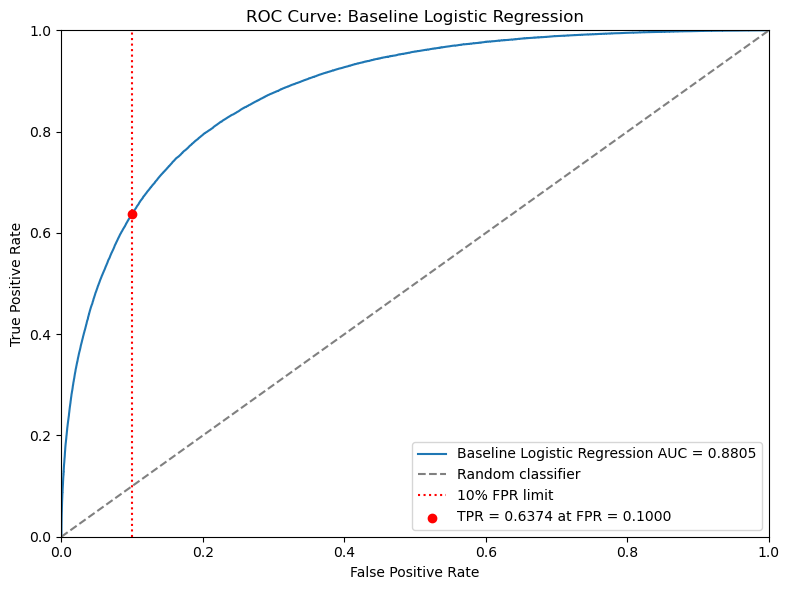

Saved ROC curve: D:\BUDT 758C - Predictive analytics\project work\baseline_logreg_roc_curve.png
Saved baseline metrics: D:\BUDT 758C - Predictive analytics\project work\baseline_logreg_validation_metrics.csv
                          model       auc  fpr_limit  fpr_at_threshold  \
0  Baseline Logistic Regression  0.880496        0.1          0.099969   

   tpr_at_10pct_fpr  threshold  accuracy      tn     fp     fn     tp  \
0          0.637448    0.66632   0.86821  249513  27714  13860  24369   

                                      roc_curve_path  
0  D:\BUDT 758C - Predictive analytics\project wo...  


In [15]:
# ============================================================
# 15. Baseline ROC Curve and TPR at 10% FPR
# ============================================================

baseline_metrics = best_tpr_under_fpr(
    y_val,
    baseline_val_score,
    fpr_limit=FPR_LIMIT
)

print_metrics("BASELINE LOGISTIC REGRESSION VALIDATION METRICS", baseline_metrics)

roc_curve_path = plot_roc_with_operating_point(
    y_true=y_val,
    y_score=baseline_val_score,
    metrics=baseline_metrics,
    output_dir=OUTPUT_DIR,
    filename="baseline_logreg_roc_curve.png"
)

baseline_metrics_df = pd.DataFrame([{
    "model": "Baseline Logistic Regression",
    "auc": baseline_metrics["auc"],
    "fpr_limit": FPR_LIMIT,
    "fpr_at_threshold": baseline_metrics["fpr"],
    "tpr_at_10pct_fpr": baseline_metrics["tpr"],
    "threshold": baseline_metrics["threshold"],
    "accuracy": baseline_metrics["accuracy"],
    "tn": baseline_metrics["tn"],
    "fp": baseline_metrics["fp"],
    "fn": baseline_metrics["fn"],
    "tp": baseline_metrics["tp"],
    "roc_curve_path": roc_curve_path
}])

baseline_metrics_path = os.path.join(OUTPUT_DIR, "baseline_logreg_validation_metrics.csv")
baseline_metrics_df.to_csv(baseline_metrics_path, index=False)

print("Saved baseline metrics:", baseline_metrics_path)
print(baseline_metrics_df)


## Export baseline logistic regression submission


In [16]:
# ============================================================
# 16. Export Baseline Logistic Regression Submission
# ============================================================

baseline_threshold = baseline_metrics["threshold"]
baseline_test_pred = (baseline_test_score >= baseline_threshold).astype(int)

baseline_submission = pd.DataFrame({
    "top_useful": baseline_test_pred
})

baseline_submission_path = os.path.join(OUTPUT_DIR, "group_7_yelp.csv")
baseline_submission.to_csv(
    baseline_submission_path,
    index=False,
    header=False
)

baseline_score_path = os.path.join(OUTPUT_DIR, "baseline_logreg_test_scores.csv")
pd.DataFrame({
    "baseline_logreg_score": baseline_test_score,
    "prediction": baseline_test_pred
}).to_csv(baseline_score_path, index=False)

baseline_summary = {
    "model": "Baseline Logistic Regression",
    "validation_auc": baseline_metrics["auc"],
    "validation_fpr": baseline_metrics["fpr"],
    "validation_tpr_at_10pct_fpr": baseline_metrics["tpr"],
    "threshold": baseline_threshold,
    "positive_predictions": int(baseline_test_pred.sum()),
    "positive_ratio": float(baseline_test_pred.mean())
}

baseline_summary_path = os.path.join(OUTPUT_DIR, "baseline_logreg_final_summary.csv")
pd.DataFrame([baseline_summary]).to_csv(baseline_summary_path, index=False)

print("Submission:", baseline_submission_path)
print("Scores:", baseline_score_path)
print("Summary:", baseline_summary_path)
print("Positive predictions:", baseline_test_pred.sum())
print("Positive ratio:", baseline_test_pred.mean())
print("Validation FPR:", baseline_metrics["fpr"])
print("Validation TPR at 10% FPR:", baseline_metrics["tpr"])


Submission: D:\BUDT 758C - Predictive analytics\project work\group_7_yelp.csv
Scores: D:\BUDT 758C - Predictive analytics\project work\baseline_logreg_test_scores.csv
Summary: D:\BUDT 758C - Predictive analytics\project work\baseline_logreg_final_summary.csv
Positive predictions: 104137
Positive ratio: 0.14876714285714285
Validation FPR: 0.09996861777532491
Validation TPR at 10% FPR: 0.6374480106725261
